In [2]:
print("Antas")

Antas


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("/content/30k_ppd_CTGAN.csv")
df.head()

,Age,Gestational Age,Number of sons,Number of daughters,Total Number of Children,Gravida,Female Education,Husband Education,Working Status,Physical Health,...,"Feeling down, depressed, or hopeless",Trouble falling or staying sleep or sleeping too much,Feeling tired or having little energy,Poor appetite or overeating,Feeling badabout yourself that you are failure or have let yourself or your family down,"Trouble concentrating on things, such as reading the newspaper or watching television",Moving or speaking so slowly that other people could have Noticed.,"Thoughts that you would be better off dead, or of hurting yourself",Scalling,Labelling
0,25.0,26,0,0,0,Primigravida,Graduation,Graduation,Housewife,Healthy,...,3,1,1,2,2,3,2.0,1.0,16,1
1,28.0,35,0,1,1,Multigravida,Intermediate,Matric,Working Lady,Healthy,...,2,3,0,3,1,2,0.0,1.0,13,1
2,26.0,28,0,0,0,Primigravida,Graduation,Graduation,Housewife,Healthy,...,1,3,2,0,3,3,0.0,0.0,13,1
3,25.0,28,0,1,1,Multigravida,Graduation,Graduation,Housewife,Healthy,...,0,3,3,3,1,3,3.0,0.0,17,1
4,24.0,39,0,0,0,Primigravida,Graduation,Graduation,Housewife,Healthy,...,1,0,1,1,0,0,0.0,0.0,5,0


In [5]:
# Task 1: Convert Age from float to int
# Handling any potential NaNs just in case
df['Age'] = df['Age'].fillna(df['Age'].mean()).round().astype(int)

# Task 2: Convert specific columns to int in range (0-3) based on the specified rules
col1 = 'Moving or speaking so slowly that other people could have Noticed.'
col2 = 'Thoughts that you would be better off dead, or of hurting yourself'

def categorize_score(x):
    if pd.isna(x):
        return 0
    if x < 0.5:
        return 0
    elif x < 1.5:
        return 1
    elif x < 2.5:
        return 2
    else:
        return 3

if col1 in df.columns:
    df[col1] = df[col1].apply(categorize_score).astype(int)
else:
    print(f"Column not found: {col1}")

if col2 in df.columns:
    df[col2] = df[col2].apply(categorize_score).astype(int)
else:
    print(f"Column not found: {col2}")

# Save the updated DataFrame
output_file = '30k_ppd_CTGAN_cleaned.csv'
df.to_csv(output_file, index=False)

# Display a preview to confirm the changes
print("Modifications successful! Here is a preview of the transformed columns:")
print(df[['Age', col1, col2]].head(10))
print(f"\nSaved updated dataset to {output_file}")

Modifications successful! Here is a preview of the transformed columns:
   Age  Moving or speaking so slowly that other people could have Noticed.  \
0   25                                                  2                    
1   28                                                  0                    
2   26                                                  0                    
3   25                                                  3                    
4   24                                                  0                    
5   27                                                  1                    
6   25                                                  3                    
7   31                                                  1                    
8   25                                                  1                    
9   25                                                  1                    

   Thoughts that you would be better off dead, or of hurting yourself

/tmp/ipython-input-3992363673.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data= df, x='Labelling', palette=['#2ecc71', '#e74c3c'])


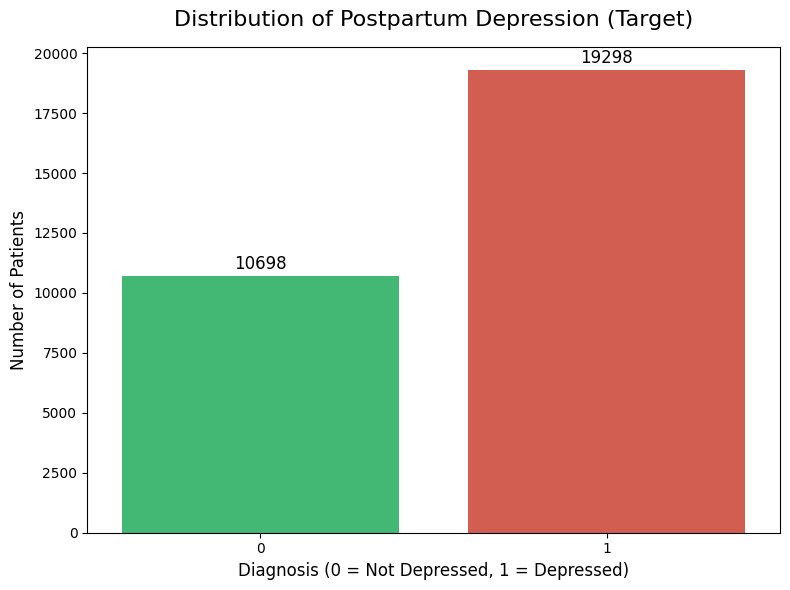

In [8]:
# Target Variable Distribution
plt.figure(figsize=(8, 6))
ax = sns.countplot(data= df, x='Labelling', palette=['#2ecc71', '#e74c3c'])

plt.title('Distribution of Postpartum Depression (Target)', fontsize=16, pad=15)
plt.xlabel('Diagnosis (0 = Not Depressed, 1 = Depressed)', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

# Add exact counts on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

In [10]:
# Statistical Validation (KS Test)
from scipy.stats import ks_2samp
print("--- Running Kolmogorov-Smirnov (KS) Test ---")

# Split back into real and synthetic for the test
num_real_rows = 14000
real_data = df.iloc[:num_real_rows]
synthetic_data = df.iloc[num_real_rows:]

# Test the numerical continuous columns
numerical_cols = ['Age', 'Gestational Age', 'Number of sons', 'Number of daughters',
                  'Total Number of Children', 'Scalling']

ks_results = []
for col in numerical_cols:
    stat, p_value = ks_2samp(real_data[col], synthetic_data[col])
    ks_results.append({
        'Feature': col,
        'KS-Statistic': round(stat, 4),
        'P-Value': round(p_value, 4),
        'Identical Distribution?': 'Yes' if p_value > 0.05 else 'No'
    })

ks_df = pd.DataFrame(ks_results)
display(ks_df)

--- Running Kolmogorov-Smirnov (KS) Test ---


,Feature,KS-Statistic,P-Value,Identical Distribution?
0,Age,0.0620,0.0,No
1,Gestational Age,0.0545,0.0,No
2,Number of sons,0.0528,0.0,No
3,Number of daughters,0.0278,0.0,No
4,Total Number of Children,0.0442,0.0,No
5,Scalling,0.0639,0.0,No


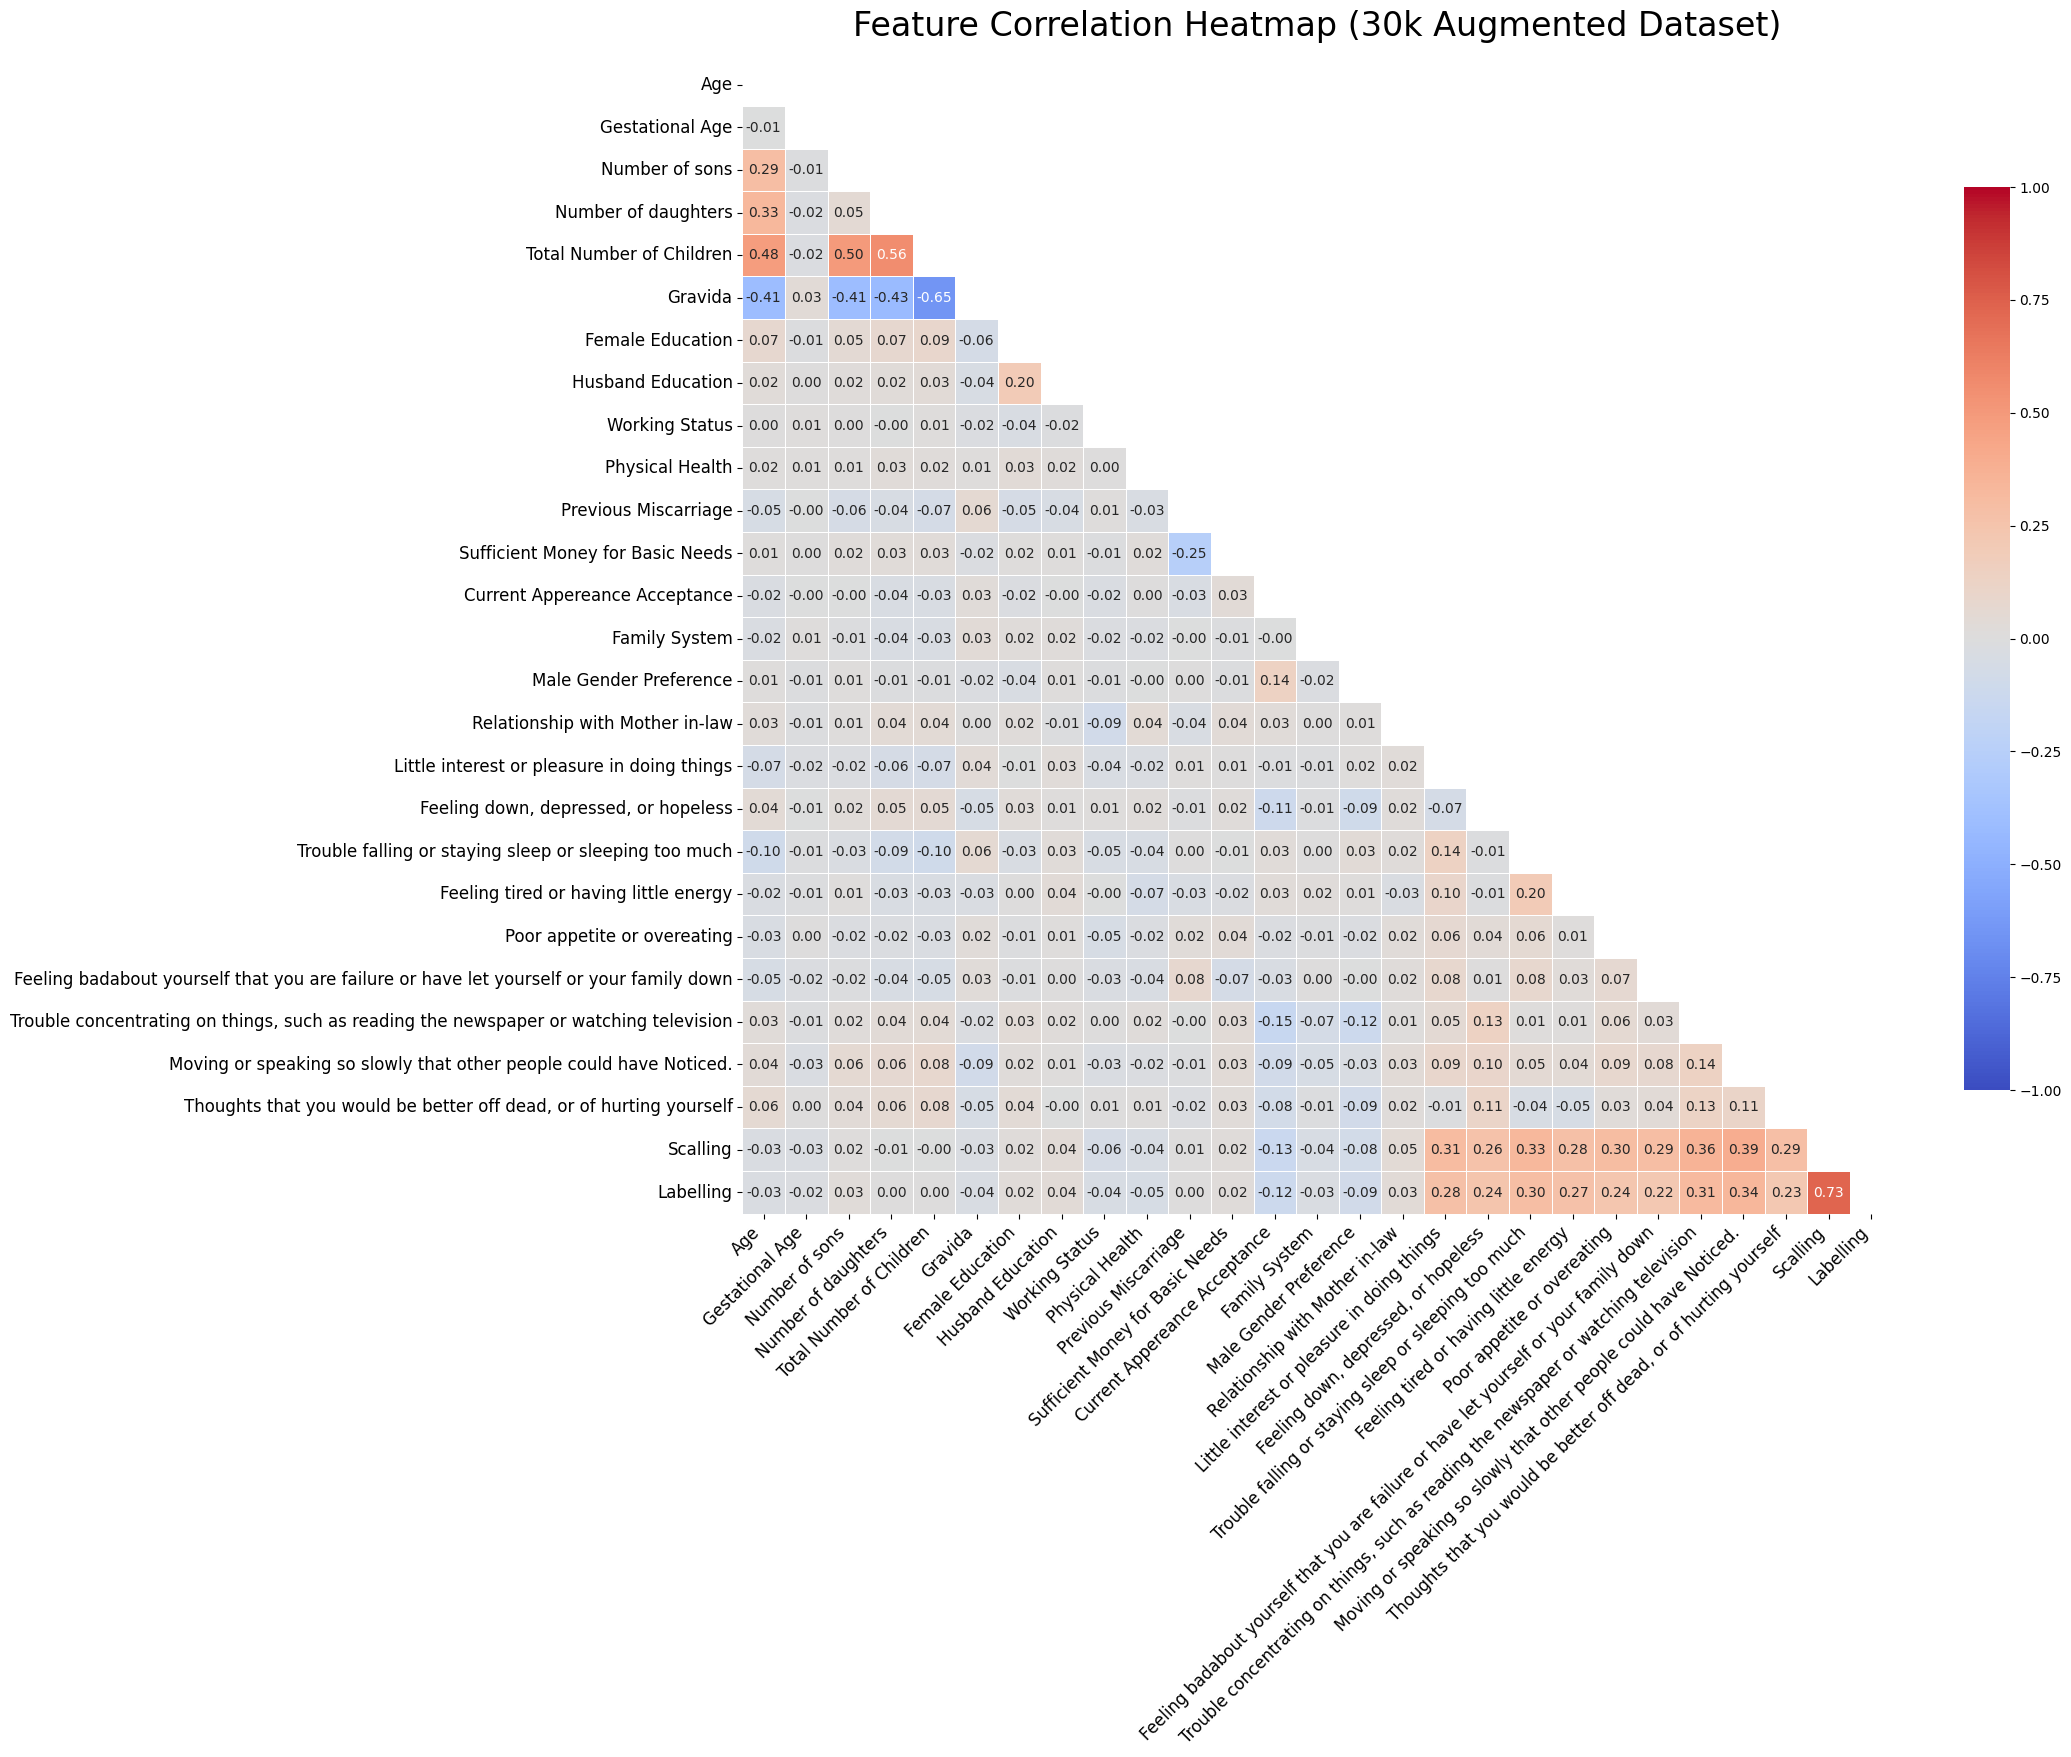


Top 10 Risk Factors Correlated with PPD:
Scalling                                                                                   0.727357
Moving or speaking so slowly that other people could have Noticed.                         0.338412
Trouble concentrating on things, such as reading the newspaper or watching television      0.314809
Trouble falling or staying sleep or sleeping too much                                      0.296289
Little interest or pleasure in doing things                                                0.279017
Feeling tired or having little energy                                                      0.271585
Feeling down, depressed, or hopeless                                                       0.242717
Poor appetite or overeating                                                                0.235207
Thoughts that you would be better off dead, or of hurting yourself                         0.226245
Feeling badabout yourself that you are failure or have let

In [11]:
# Correlation Heatmap
from sklearn.preprocessing import LabelEncoder
# Create a temporary copy to safely encode text into numbers for math
df_encoded = df.copy()
le = LabelEncoder()

cat_cols = df_encoded.select_dtypes(include=['object']).columns
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# Calculate correlations
plt.figure(figsize=(22, 18))
corr_matrix = df_encoded.corr()

# Create a mask to hide the top-right triangle (prevents duplicate data)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Draw the heatmap
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .75})

plt.title('Feature Correlation Heatmap (30k Augmented Dataset)', fontsize=24, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

# Print Top 10 Features most correlated with PPD
print("\nTop 10 Risk Factors Correlated with PPD:")
top_correlations = corr_matrix['Labelling'].sort_values(ascending=False).drop('Labelling')
print(top_correlations.head(10))

/tmp/ipython-input-2345861591.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(ax=axes[0], data=df, x='Labelling', y='Age', palette=['#3498db', '#e74c3c'])
/tmp/ipython-input-2345861591.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(ax=axes[1], data=df, x='Labelling', y='Scalling', palette=['#3498db', '#e74c3c'])


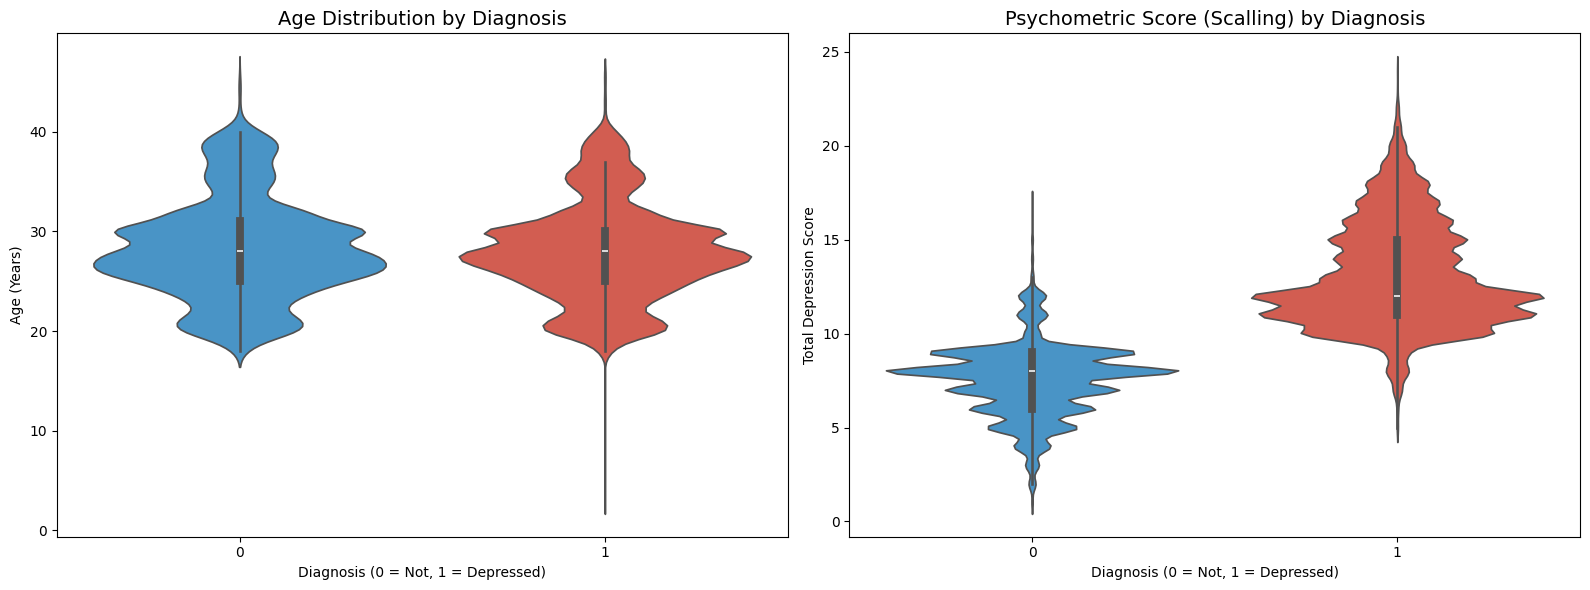

In [12]:
# BLOCK 5: Distribution Analysis (Violin Plots)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Age vs Depression
sns.violinplot(ax=axes[0], data=df, x='Labelling', y='Age', palette=['#3498db', '#e74c3c'])
axes[0].set_title('Age Distribution by Diagnosis', fontsize=14)
axes[0].set_xlabel('Diagnosis (0 = Not, 1 = Depressed)')
axes[0].set_ylabel('Age (Years)')

# Plot 2: Scalling vs Depression
sns.violinplot(ax=axes[1], data=df, x='Labelling', y='Scalling', palette=['#3498db', '#e74c3c'])
axes[1].set_title('Psychometric Score (Scalling) by Diagnosis', fontsize=14)
axes[1].set_xlabel('Diagnosis (0 = Not, 1 = Depressed)')
axes[1].set_ylabel('Total Depression Score')

plt.tight_layout()
plt.show()

In [13]:
# Label Encoding for all Categorical Features
# 1. Load the cleaned 30k dataset
df_model = pd.read_csv('30k_ppd_CTGAN_cleaned.csv')

# 2. Initialize LabelEncoder
le = LabelEncoder()

# 3. Automatically find all text (object) columns
categorical_cols = df_model.select_dtypes(include=['object']).columns
print(f"Found {len(categorical_cols)} text columns to encode:\n{list(categorical_cols)}\n")

# 4. Apply Label Encoding to each text column
for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print("Label Encoding Complete! Here is a preview of the encoded data:")
display(df_model.head())

Found 11 text columns to encode:
['Gravida', 'Female Education', 'Husband Education', 'Working Status', 'Physical Health', 'Previous Miscarriage', 'Sufficient Money for Basic Needs', 'Current Appereance Acceptance', 'Family System', 'Male Gender Preference', 'Relationship with Mother in-law']

Label Encoding Complete! Here is a preview of the encoded data:


,Age,Gestational Age,Number of sons,Number of daughters,Total Number of Children,Gravida,Female Education,Husband Education,Working Status,Physical Health,...,"Feeling down, depressed, or hopeless",Trouble falling or staying sleep or sleeping too much,Feeling tired or having little energy,Poor appetite or overeating,Feeling badabout yourself that you are failure or have let yourself or your family down,"Trouble concentrating on things, such as reading the newspaper or watching television",Moving or speaking so slowly that other people could have Noticed.,"Thoughts that you would be better off dead, or of hurting yourself",Scalling,Labelling
0,25,26,0,0,0,2,0,0,0,1,...,3,1,1,2,2,3,2,1,16,1
1,28,35,0,1,1,0,1,2,1,1,...,2,3,0,3,1,2,0,1,13,1
2,26,28,0,0,0,2,0,0,0,1,...,1,3,2,0,3,3,0,0,13,1
3,25,28,0,1,1,0,0,0,0,1,...,0,3,3,3,1,3,3,0,17,1
4,24,39,0,0,0,2,0,0,0,1,...,1,0,1,1,0,0,0,0,5,0


In [14]:
#Train/Test Split
from sklearn.model_selection import train_test_split

# Separate the Features (X) from the Target (y)
X = df_model.drop('Labelling', axis=1)
y = df_model['Labelling']

# Perform the 80/20 split
# stratify=y ensures both train and test sets have an equal 50/50 mix of Depressed/Not Depressed
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Training Data: {X_train.shape[0]} rows")
print(f"Testing Data:  {X_test.shape[0]} rows")

Training Data: 23996 rows
Testing Data:  6000 rows


In [15]:
# BLOCK 3: Save to CSV
# Recombine X and y for the training set
train_data = X_train.copy()
train_data['Labelling'] = y_train

# Recombine X and y for the testing set
test_data = X_test.copy()
test_data['Labelling'] = y_test

# Save them to your Colab environment
train_data.to_csv('train.csv', index=False)
test_data.to_csv('test.csv', index=False)

print("Successfully saved 'train.csv' and 'test.csv'!")

Successfully saved 'train.csv' and 'test.csv'!
